In [9]:
# ============================================================
# MODULO 3 — TIME SERIES CLUSTERING
# 2 algoritmi (K-means distance-based + Hierarchical), 2 riduzioni (PCA + t-SNE)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ricarico il dataset standardizzato salvato nel preprocessing
ts_scaled = pd.read_csv("cmi_ts_standardized.csv")
time_series_cols = [str(i) for i in range(200)]

X_clust = ts_scaled[time_series_cols].values   # (4437, 200)
y_true  = ts_scaled["sii_binary"].values       # per la purity
print("Matrice clustering:", X_clust.shape)

Matrice clustering: (4437, 200)


C:\Users\marco\anaconda3\envs\dm2_shap\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


k=2: SSE=178, silhouette=0.034
k=3: SSE=174, silhouette=0.028
k=4: SSE=171, silhouette=0.028
k=5: SSE=169, silhouette=0.028
k=6: SSE=167, silhouette=0.029
k=7: SSE=165, silhouette=0.031
k=8: SSE=163, silhouette=0.030


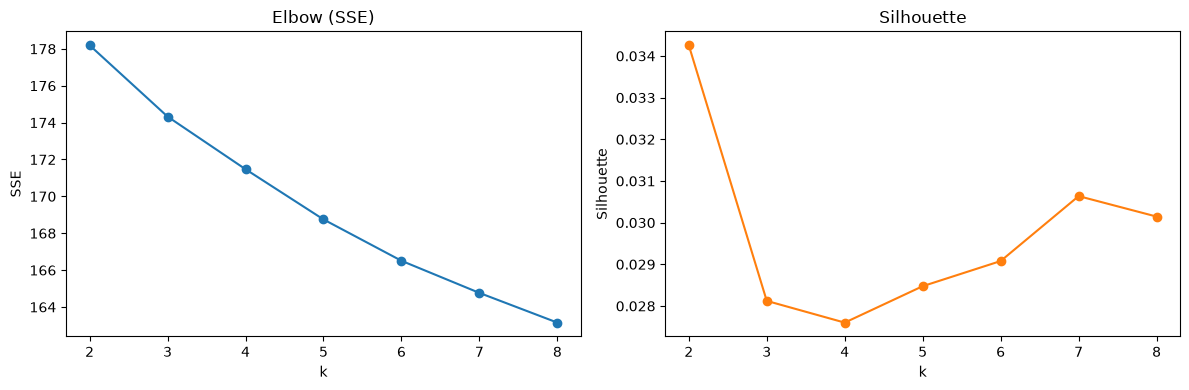

In [15]:
# ── Scelta del numero di cluster: silhouette + SSE (metodo del gomito) ──
from tslearn.clustering import TimeSeriesKMeans, silhouette_score

sse, sil = [], []
K_range = range(2, 9)
for k in K_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="euclidean", random_state=0, max_iter=20)
    labels = km.fit_predict(X_clust)
    sse.append(km.inertia_)
    sil.append(silhouette_score(X_clust, labels, metric="euclidean"))
    print(f"k={k}: SSE={km.inertia_:.0f}, silhouette={sil[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K_range), sse, marker='o'); ax[0].set_xlabel('k'); ax[0].set_ylabel('SSE'); ax[0].set_title('Elbow (SSE)')
ax[1].plot(list(K_range), sil, marker='o', color='C1'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette'); ax[1].set_title('Silhouette')
plt.tight_layout()
plt.savefig('ts_clustering_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

K-means euclideo — distribuzione cluster: [676 525 849 489 573 695 630]


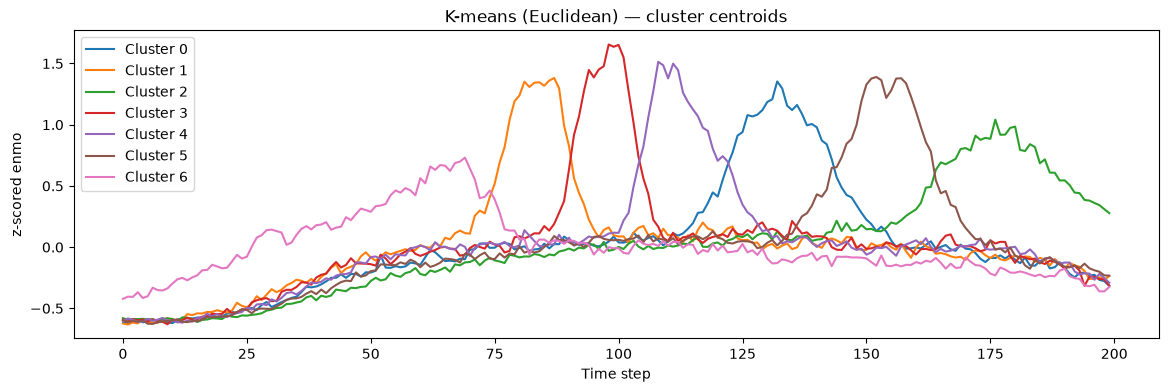

In [17]:
# ── Algoritmo 1: K-means con distanza EUCLIDEA ───────────────
# Euclidea: veloce, adatta perche' le serie hanno tutte la stessa lunghezza
# (200) e sono gia' allineate temporalmente (stesso asse orario).
K = 7  # scegli in base ai grafici sopra
km_eucl = TimeSeriesKMeans(n_clusters=K, metric="euclidean", random_state=0, max_iter=50)
labels_eucl = km_eucl.fit_predict(X_clust)
print("K-means euclideo — distribuzione cluster:", np.bincount(labels_eucl))

# Centroidi
plt.figure(figsize=(14, 4))
for c in range(K):
    plt.plot(km_eucl.cluster_centers_[c].ravel(), label=f'Cluster {c}')
plt.title("K-means (Euclidean) — cluster centroids")
plt.xlabel("Time step"); plt.ylabel("z-scored enmo"); plt.legend()
plt.savefig('ts_kmeans_euclidean_centroids.png', dpi=300, bbox_inches='tight')
plt.show()

K-means DTW — distribuzione cluster: [ 165 1067  246  671  650  622 1016]


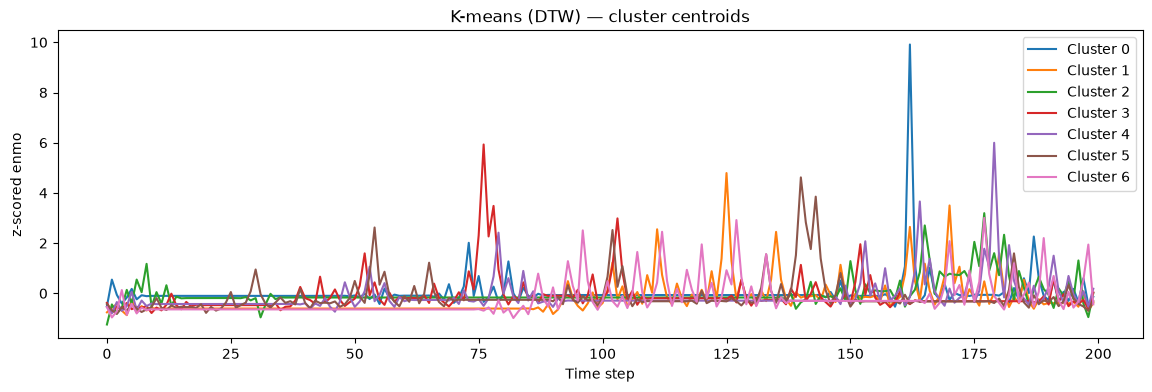

In [19]:
# ── Algoritmo 1b: K-means con distanza DTW ───────────────────
# DTW: allinea in modo elastico serie leggermente sfasate nel tempo
# (es. un bambino che fa la stessa attivita' mezz'ora dopo un altro).
# Piu' lento (~4 min su 4437 serie) ma cattura somiglianze di forma
# che l'euclidea rigida perde.
km_dtw = TimeSeriesKMeans(n_clusters=K, metric="dtw", random_state=0,
                          max_iter=10, max_iter_barycenter=10)
labels_dtw = km_dtw.fit_predict(X_clust)
print("K-means DTW — distribuzione cluster:", np.bincount(labels_dtw))

plt.figure(figsize=(14, 4))
for c in range(K):
    plt.plot(km_dtw.cluster_centers_[c].ravel(), label=f'Cluster {c}')
plt.title("K-means (DTW) — cluster centroids")
plt.xlabel("Time step"); plt.ylabel("z-scored enmo"); plt.legend()
plt.savefig('ts_kmeans_dtw_centroids.png', dpi=300, bbox_inches='tight')
plt.show()

Hierarchical — distribuzione cluster: [1124  482  674  494  348  511  804]
Silhouette hierarchical: 0.01145063247492784


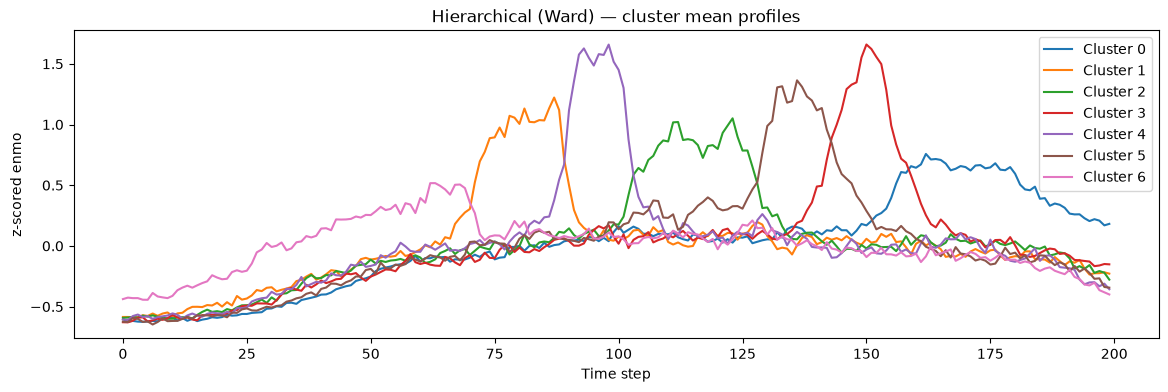

In [20]:
# ── Algoritmo 2: Hierarchical clustering (Ward) ──────────────
# Secondo algoritmo, di famiglia diversa (agglomerativo): parte da ogni
# serie come cluster singolo e li fonde minimizzando la varianza interna.
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score as sk_silhouette

hier = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_hier = hier.fit_predict(X_clust)
print("Hierarchical — distribuzione cluster:", np.bincount(labels_hier))
print("Silhouette hierarchical:", sk_silhouette(X_clust, labels_hier))

# Centroidi (media delle serie in ogni cluster)
plt.figure(figsize=(14, 4))
for c in range(K):
    plt.plot(X_clust[labels_hier == c].mean(axis=0), label=f'Cluster {c}')
plt.title("Hierarchical (Ward) — cluster mean profiles")
plt.xlabel("Time step"); plt.ylabel("z-scored enmo"); plt.legend()
plt.savefig('ts_hierarchical_centroids.png', dpi=300, bbox_inches='tight')
plt.show()

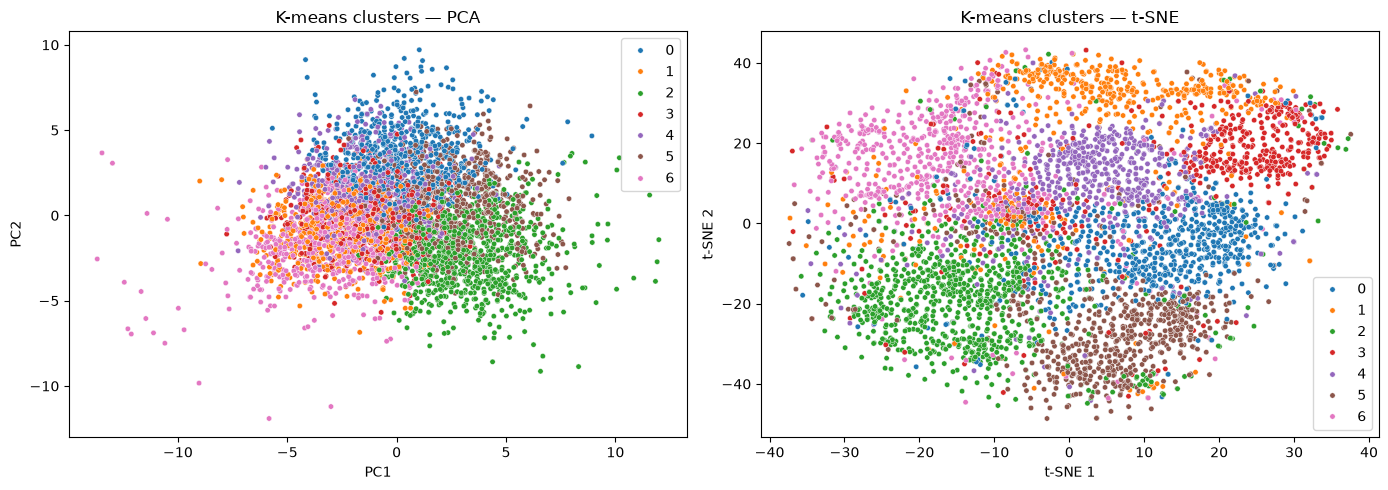

In [21]:
# ── Visualizzazione con 2 tecniche di riduzione: PCA + t-SNE ─
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_clust)

tsne = TSNE(n_components=2, random_state=0, perplexity=30)
X_tsne = tsne.fit_transform(X_clust)   # ~30s

# Visualizzo i cluster K-means euclideo con entrambe le proiezioni
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_eucl, palette='tab10', s=15, ax=axes[0], legend='full')
axes[0].set_title("K-means clusters — PCA"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels_eucl, palette='tab10', s=15, ax=axes[1], legend='full')
axes[1].set_title("K-means clusters — t-SNE"); axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig('ts_clusters_pca_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# ── Purity: i cluster catturano il target sii_binary? ────────
# Per ogni cluster guardo la classe maggioritaria; la purity media dice
# quanto i cluster "trovati senza supervisione" coincidono col target.
def purity_score(labels, y):
    df_p = pd.DataFrame({'cluster': labels, 'y': y})
    correct = df_p.groupby('cluster')['y'].apply(lambda s: s.value_counts().iloc[0]).sum()
    return correct / len(y)

print("Purity K-means euclideo:", round(purity_score(labels_eucl, y_true), 3))
print("Purity K-means DTW:     ", round(purity_score(labels_dtw, y_true), 3))
print("Purity Hierarchical:    ", round(purity_score(labels_hier, y_true), 3))

# Distribuzione del target dentro ogni cluster (K-means euclideo)
print("\nDistribuzione sii_binary per cluster (K-means euclideo):")
print(pd.crosstab(labels_eucl, y_true, normalize='index').round(2))

Purity K-means euclideo: 0.666
Purity K-means DTW:      0.666
Purity Hierarchical:     0.666

Distribuzione sii_binary per cluster (K-means euclideo):
col_0     0     1
row_0            
0      0.72  0.28
1      0.64  0.36
2      0.69  0.31
3      0.69  0.31
4      0.64  0.36
5      0.70  0.30
6      0.56  0.44


In [27]:
# ============================================================
# MODULO 3 — TIME SERIES CLUSTERING (MULTIVARIATO: enmo+anglez+light)
# 2 algoritmi (K-means dist-based + Hierarchical), 2 riduzioni (PCA + t-SNE)
# ============================================================
import gzip, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with gzip.open("CMI_timeseries_dataset.pkl.gz", "rb") as f:
    CMI = pickle.load(f)

# ── Costruzione del tensore multivariato ─────────────────────
# Ogni serie diventa (200 timestep x 3 canali). z-score PER CANALE
# (non globale!) perche' enmo~[0,7], anglez~[-90,90], light~[0,2600]:
# senza normalizzazione separata, light dominerebbe la distanza.
CANALI = ["enmo", "anglez", "light"]

def zscore(a):
    a = a.astype(float)
    return (a - a.mean()) / (a.std() + 1e-9)

X_mv = np.stack([
    np.column_stack([zscore(ts[ch].values) for ch in CANALI])
    for ts in CMI
])                                        # shape (4437, 200, 3)
y_true = np.array([ts["sii_binary"].iloc[0] for ts in CMI])
groups = np.array([ts["id"].iloc[0] for ts in CMI])

X_flat = X_mv.reshape(len(X_mv), -1)      # (4437, 600) per algoritmi/viz che vogliono 2D
print("Tensore multivariato:", X_mv.shape, "| appiattito:", X_flat.shape)

Tensore multivariato: (4437, 200, 3) | appiattito: (4437, 600)


k=2: SSE=563, silhouette=0.021
k=3: SSE=555, silhouette=0.017
k=4: SSE=550, silhouette=0.016
k=5: SSE=544, silhouette=0.017
k=6: SSE=541, silhouette=0.015
k=7: SSE=537, silhouette=0.016


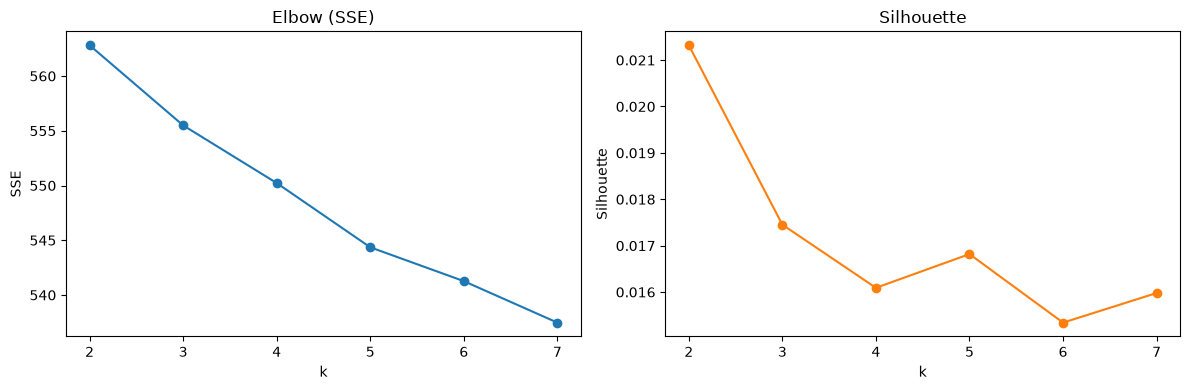

In [29]:
# ── Scelta di k: silhouette + SSE ────────────────────────────
from tslearn.clustering import TimeSeriesKMeans, silhouette_score

sse, sil = [], []
K_range = range(2, 8)
for k in K_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="euclidean", random_state=0, max_iter=20)
    lab = km.fit_predict(X_mv)
    sse.append(km.inertia_)
    sil.append(silhouette_score(X_mv, lab, metric="euclidean"))
    print(f"k={k}: SSE={km.inertia_:.0f}, silhouette={sil[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K_range), sse, marker='o'); ax[0].set_xlabel('k'); ax[0].set_ylabel('SSE'); ax[0].set_title('Elbow (SSE)')
ax[1].plot(list(K_range), sil, marker='o', color='C1'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette'); ax[1].set_title('Silhouette')
plt.tight_layout()
plt.savefig('ts_mv_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

K-means euclideo — distribuzione: [1090 1630 1717]


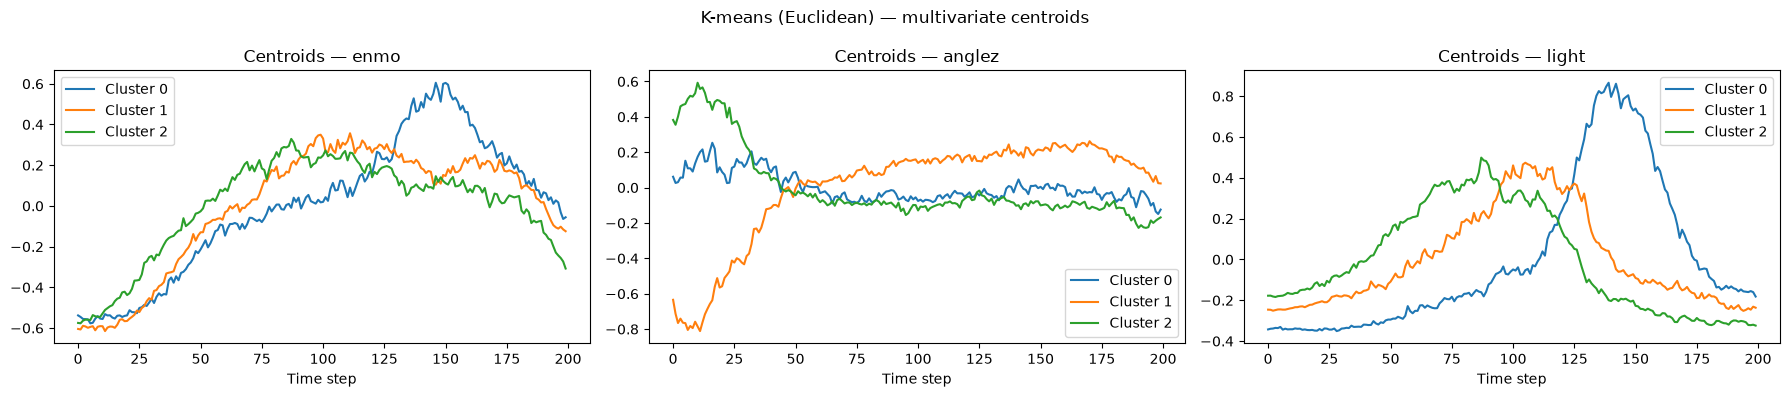

In [30]:
# ── Algoritmo 1: K-means EUCLIDEO (multivariato) ─────────────
K = 3   # scegli in base ai grafici sopra
km_eucl = TimeSeriesKMeans(n_clusters=K, metric="euclidean", random_state=0, max_iter=50)
labels_eucl = km_eucl.fit_predict(X_mv)
print("K-means euclideo — distribuzione:", np.bincount(labels_eucl))

# Centroidi: un pannello per canale (il centroide e' multi-canale!)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ch_idx, ch in enumerate(CANALI):
    for c in range(K):
        axes[ch_idx].plot(km_eucl.cluster_centers_[c][:, ch_idx], label=f'Cluster {c}')
    axes[ch_idx].set_title(f"Centroids — {ch}"); axes[ch_idx].set_xlabel("Time step"); axes[ch_idx].legend()
plt.suptitle("K-means (Euclidean) — multivariate centroids")
plt.tight_layout()
plt.savefig('ts_mv_kmeans_euclidean_centroids.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# ── Algoritmo 1b: K-means DTW (multivariato) ─────────────────
# DTW multivariato "dependent": allinea i 3 canali insieme.
# Piu' lento (~qualche minuto) ma tollera sfasamenti temporali.
km_dtw = TimeSeriesKMeans(n_clusters=K, metric="dtw", random_state=0,
                          max_iter=10, max_iter_barycenter=10)
labels_dtw = km_dtw.fit_predict(X_mv)
print("K-means DTW — distribuzione:", np.bincount(labels_dtw))
print("Silhouette DTW:", round(silhouette_score(X_mv, labels_dtw, metric="dtw"), 3))

K-means DTW — distribuzione: [ 725 2069 1643]
Silhouette DTW: 0.021


In [32]:
# ── Algoritmo 2: Hierarchical (Ward) sul multivariato appiattito ──
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score as sk_silhouette

hier = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_hier = hier.fit_predict(X_flat)
print("Hierarchical — distribuzione:", np.bincount(labels_hier))
print("Silhouette hierarchical:", round(sk_silhouette(X_flat, labels_hier), 3))

Hierarchical — distribuzione: [2991  748  698]
Silhouette hierarchical: 0.01


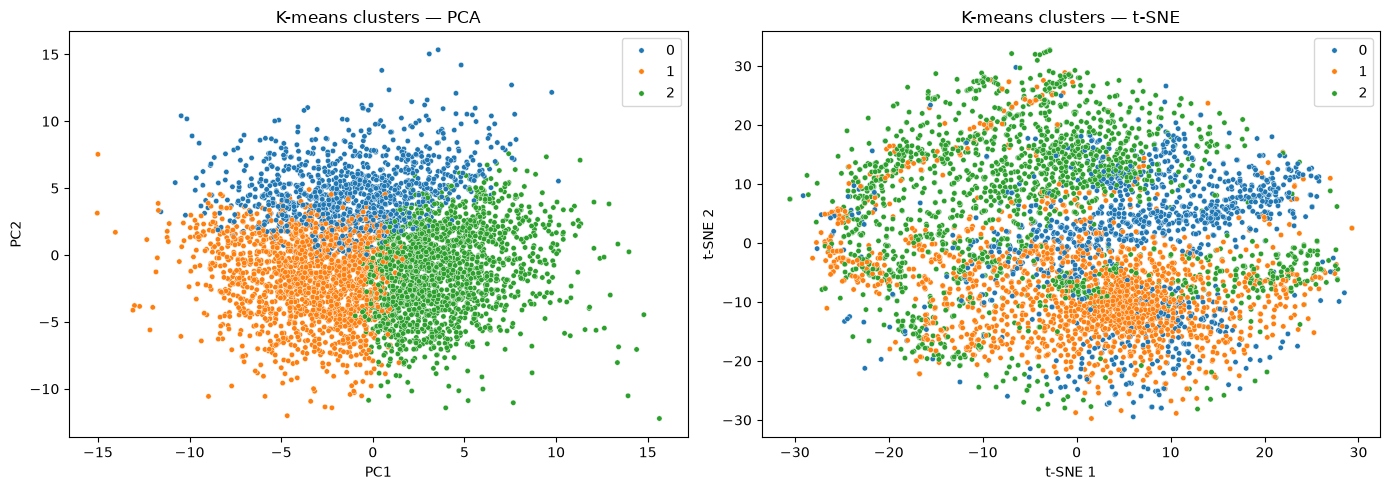

In [33]:
# ── Visualizzazione: PCA + t-SNE (2 riduzioni richieste) ─────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_pca  = PCA(n_components=2, random_state=0).fit_transform(X_flat)
X_tsne = TSNE(n_components=2, random_state=0, perplexity=30).fit_transform(X_flat)  # ~40s

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_eucl, palette='tab10', s=15, ax=axes[0], legend='full')
axes[0].set_title("K-means clusters — PCA"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels_eucl, palette='tab10', s=15, ax=axes[1], legend='full')
axes[1].set_title("K-means clusters — t-SNE"); axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig('ts_mv_clusters_pca_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# ── Purity verso sii_binary + distribuzione target per cluster ──
def purity_score(labels, y):
    d = pd.DataFrame({'cluster': labels, 'y': y})
    correct = d.groupby('cluster')['y'].apply(lambda s: s.value_counts().iloc[0]).sum()
    return correct / len(y)

print("Purity K-means euclideo:", round(purity_score(labels_eucl, y_true), 3))
print("Purity K-means DTW:     ", round(purity_score(labels_dtw, y_true), 3))
print("Purity Hierarchical:    ", round(purity_score(labels_hier, y_true), 3))
print("\nDistribuzione sii_binary per cluster (K-means euclideo):")
print(pd.crosstab(labels_eucl, y_true, normalize='index').round(2))

Purity K-means euclideo: 0.666
Purity K-means DTW:      0.666
Purity Hierarchical:     0.666

Distribuzione sii_binary per cluster (K-means euclideo):
col_0     0     1
row_0            
0      0.68  0.32
1      0.66  0.34
2      0.66  0.34
